In [ ]:
!pip install tensorflow_datasets

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Download the dataset
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.X9O0UQ_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
class_names = info.features['label'].names
class_names

['cat', 'dog']

In [ ]:
for i, example in enumerate(dataset['train']):
  image, label = example
  save_dir = './cats_vs_dogs/train/{}'.format(class_names[label])
  os.makedirs(save_dir, exist_ok=True)
  filename = save_dir + "/" + "{}_{}.jpg".format(class_names[label], i)
  tf.keras.preprocessing.image.save_img(filename, image.numpy())
  #print(save_dir)
  #break

CNN Building Blocks

*   Input layer
*   Convolution layer


*   Polling layer
*   Dropout layer


*   Batch Normalization layer
*   Activation layer

*   Fully Connected layer
*   Flatten layer

*   Output layer












In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

In [ ]:
datagen = ImageDataGenerator(rescale=1/255, validation_split=0.2, rotation_range=10,
                             width_shift_range=0.1, height_shift_range=0.1,
                             shear_range=0.1, zoom_range=0.1, horizontal_flip=True)
train_generator = datagen.flow_from_directory('/content/cats_vs_dogs/train',
                                              target_size=(150, 150),
                                              batch_size=32, class_mode='binary',
                                              subset='training')
validation_generator = datagen.flow_from_directory('/content/cats_vs_dogs/train',
                                              target_size=(150, 150),
                                              batch_size=32, class_mode='binary',
                                              subset='validation')

Found 18611 images belonging to 2 classes.
Found 4651 images belonging to 2 classes.


CNN model

In [ ]:
from tensorflow.keras.backend import batch_normalization
model = Sequential()
# 1st layer
model.add(Conv2D(32,kernel_size=3, activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPool2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.2))
# 2nd layer
model.add(Conv2D(64,kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.2))
# 3rd layer
model.add(Conv2D(128,kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,073 (72.61 MB)

 Trainable params: 19,034,625 (72.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(train_generator, epochs=50, validation_data=validation_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 171s 276ms/step - accuracy: 0.6213 - loss: 2.4575 - val_accuracy: 0.5966 - val_loss: 0.7637
Epoch 2/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 147s 253ms/step - accuracy: 0.7312 - loss: 0.5377 - val_accuracy: 0.7605 - val_loss: 0.4919
Epoch 3/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 147s 252ms/step - accuracy: 0.7539 - loss: 0.5050 - val_accuracy: 0.6715 - val_loss: 0.6586
Epoch 4/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 148s 255ms/step - accuracy: 0.7781 - loss: 0.4657 - val_accuracy: 0.7607 - val_loss: 0.4757
Epoch 5/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 149s 257ms/step - accuracy: 0.7892 - loss: 0.4431 - val_accuracy: 0.7921 - val_loss: 0.4455
Epoch 6/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 149s 257ms/step - accuracy: 0.8025 - loss: 0.4284 - val_accuracy: 0.7676 - val_loss: 0.4858
Epoch 7/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 151s 260ms/step - accuracy: 0.8201 - loss: 0.3957 - val_accuracy: 0.8329 - val_loss: 0.3719
Epoch 8/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 153s 262ms/step - accuracy: 0.8354 -

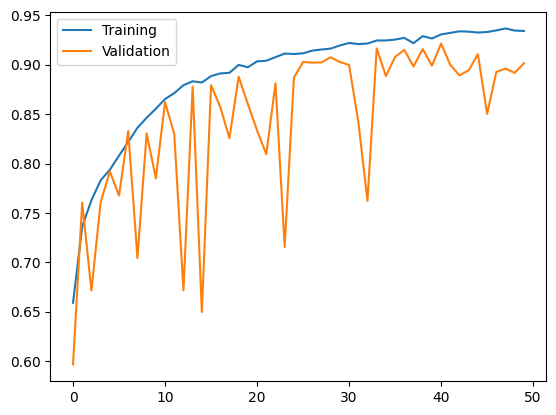

In [ ]:
history.history
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend(['Training','Validation'])
plt.show()

In [ ]:
model.save('cats_vs_dogs.h5')

In [ ]:
model_loaded = tf.keras.models.load_model('cats_vs_dogs.h5')

In [43]:
import requests
from PIL import Image
from tensorflow.keras.preprocessing import image
import io # Import the io module

img_url = "https://hips.hearstapps.com/clv.h-cdn.co/assets/16/18/gettyimages-586890581.jpg"
img = Image.open(requests.get(img_url, stream=True).raw).resize((150, 150))
image_array = image.img_to_array(img)
img = np.expand_dims(image_array, axis=0)
img = img/255.0
prediction = model_loaded.predict(img)
TH = 0.5
prediction = int(prediction[0][0]>TH)
classes = {v:k for k,v in train_generator.class_indices.items()}
classes[prediction]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


'dog'